In [1]:
using Plots
using Random

In [73]:
function reproductionProbabilitySync(age, ageThreshold)
    if age < ageThreshold
        prob = 0
    else
        prob = 1
    end
end

reproductionProbabilityNoSync(age, ageThreshold) = exp(10*log(age)) / (exp(10*log(age)) + exp(10*log(ageThreshold)))


size(Population) = length(findall(x->x>0, Population))

function simulateSync(Ninit, Nmax, ageThreshold)
    Population = zeros(Int64, Nmax)
    Population[1:Ninit] = rand(1:ageThreshold, Ninit)
    populationSize = [size(Population)]

    while populationSize[end] < Nmax
        prob = reproductionProbabilitySync.(Population, ageThreshold)
        idx = findall(x->x==1, rand(Nmax) .< prob)
        Population[idx] .= 1
        if length(idx) > 0
            aux = minimum([populationSize[end]+length(idx), Nmax])
            Population[populationSize[end]:aux] .= 1
        end
        idx = findall(x->x>0, Population)
        Population[idx] .+= 1
        push!(populationSize, size(Population))
    end
    return populationSize
end

function simulateNoSync(Ninit, Nmax, ageThreshold)
    Population = zeros(Int64, Nmax)
    Population[1:Ninit] = rand(1:ageThreshold, Ninit)
    populationSize = [size(Population)]

    while populationSize[end] < Nmax
        prob = reproductionProbabilityNoSync.(Population, ageThreshold)
        idx = findall(x->x==1, rand(Nmax) .< prob)
        Population[idx] .= 1
        if length(idx) > 0
            aux = minimum([populationSize[end]+length(idx), Nmax])
            Population[populationSize[end]:aux] .= 1
        end
        idx = findall(x->x>0, Population)
        Population[idx] .+= 1
        push!(populationSize, size(Population))
    end
    return populationSize
end



simulateNoSync (generic function with 1 method)

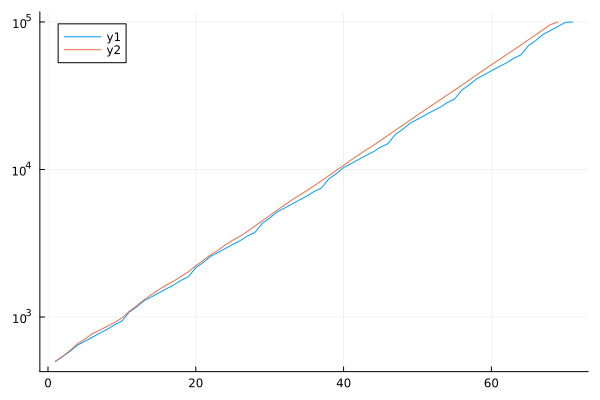

In [75]:
Ninit = 500
Nmax = 100000
ageThreshold = 10

populationSize = simulateSync(Ninit, Nmax, ageThreshold)
plot(populationSize, yaxis=:log)

populationSize = simulateNoSync(Ninit, Nmax, ageThreshold)
plot!(populationSize, yaxis=:log)


In [41]:
length(findall(x->x==10, rand(1:10, 500)))

53